# Analysing Prime Cluster Usage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import argparse
import datetime
import re
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib
from datetime import datetime

## Read qstat Data

In [2]:
# read file name cluster_usage_8thMay2025.xlsx from the current directory
# these data was collected from `qstat -fx` command output
# The oldest data we got is from Nov 14, 2024


# Read the Excel file into a DataFrame
xls = pd.ExcelFile("cluster_usage_8thMay2025.xlsx")
df = pd.read_excel(xls, sheet_name=0)

# print df info
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19895 entries, 0 to 19894
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Exit_status                19176 non-null  float64
 1   JobId                      19895 non-null  object 
 2   Job_Owner                  19894 non-null  object 
 3   job_state                  19894 non-null  object 
 4   queue =                    19894 non-null  object 
 5   Resource_List.mem          19894 non-null  object 
 6   Resource_List.ncpus        19894 non-null  float64
 7   Resource_List.ngpus        19894 non-null  float64
 8   Resource_List.nodect       19894 non-null  float64
 9   Resource_List.walltime     19894 non-null  object 
 10  resources_used.cpupercent  19301 non-null  float64
 11  resources_used.cput        19301 non-null  object 
 12  resources_used.mem         19301 non-null  object 
 13  resources_used.ncpus       19297 non-null  flo

## Calculate "how long in queue" Column

In [3]:
# calculate how long in q? column as =IF(stime="NaN", "in_q",else stime-qtime)
# convert stime and qtime to datetime
df['stime'] = pd.to_datetime(df['stime'], errors='coerce')
df['qtime'] = pd.to_datetime(df['qtime'], errors='coerce')
# calculate how long in q? column as =IF(stime="NaN", "in_q",else stime-qtime)
df['how_long_in_q'] = np.where(df['stime'].isna(), 'in_q', (df['stime'] - df['qtime']).dt.total_seconds() / (60*60) )
 
# remove "in_q" from how long in q
df['how_long_in_q'] = df['how_long_in_q'].replace('in_q', np.nan)
# convert how_long_in_q to float
df['how_long_in_q'] = df['how_long_in_q'].astype(float)
# remove NaN from how long in q
# df = df.dropna(subset=['how_long_in_q'])
# df['how_long_in_q']

## Analyse [1]: count of jobs in each queue

queue = 
def-short      5727
def-medium     3758
def-long       3215
gpus           3104
interactive    1365
preemptible    1178
condo01         532
bigmem          304
condo02         224
condo07         224
sysadmin        109
beta             67
condo04          42
training         22
sysdevel         12
condo06           7
condo05           3
condo08           1
Name: count, dtype: int64


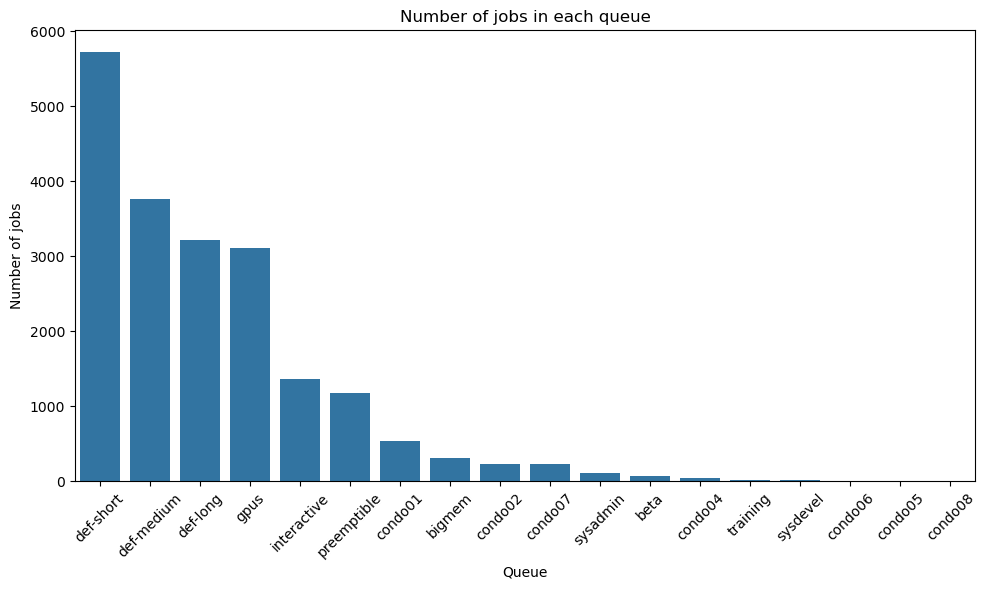

In [4]:
queue_counts = df['queue = '].value_counts()
# print the queue counts
print(queue_counts)
# plot the queue counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='queue = ', order=queue_counts.index)
plt.title('Number of jobs in each queue')
plt.xlabel('Queue')
plt.ylabel('Number of jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('queue_counts.png')
plt.show()


## Analyse [2]: jobs queue time in each queue

count    19309.000000
mean         0.972460
std          9.460009
min          0.000000
25%          0.000556
50%          0.000833
75%          0.006667
max        847.128611
Name: how_long_in_q, dtype: float64
            how_long_in_q                                 
                     mean        std       min         max
queue =                                                   
beta             0.139236   0.543329  0.000556    3.009444
bigmem          10.577299  25.731470  0.000000   93.930278
condo01          6.208999  10.794945  0.000000   39.531111
condo02          0.140510   1.470453  0.000000   15.598333
condo04          0.000456   0.000433  0.000000    0.001944
condo05          0.003750   0.003732  0.001111    0.006389
condo06          0.000833   0.000621  0.000278    0.001944
condo07          0.008314   0.066908  0.000000    0.765833
condo08          0.006944        NaN  0.006944    0.006944
def-long         2.063799   8.983016  0.000000  179.693333
def-medium       0.25

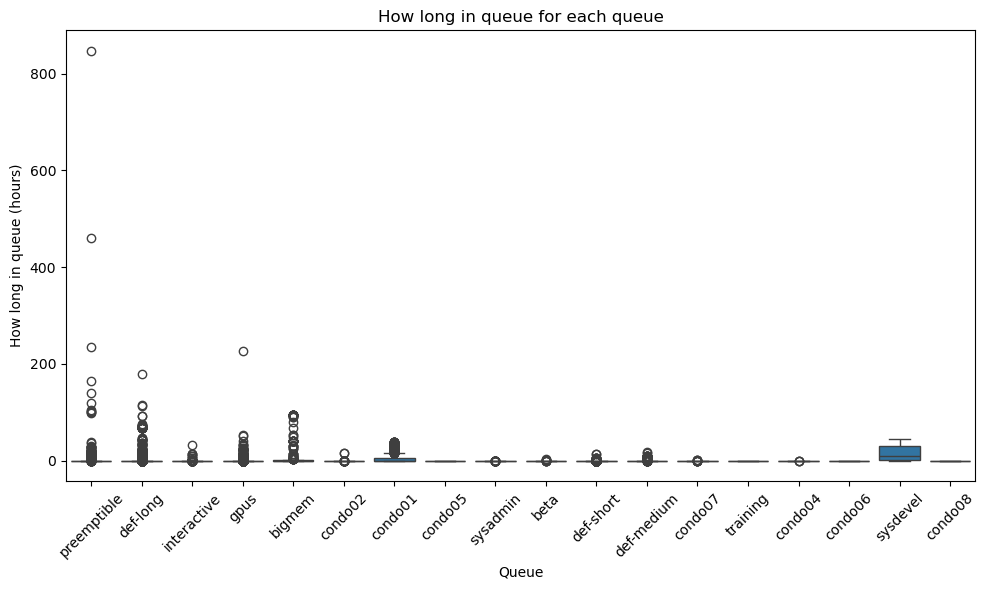

In [5]:
# another analyse the data
# do statistics on how long in q. note that how long in q is in hours and has "in_q" in it

# calculate the mean, median, std, min, max of how long in q
how_long_in_q_stats = df['how_long_in_q'].describe()
# print the stats
print(how_long_in_q_stats)


# analyse how long in q for each queue
# group by queue and calculate the mean, median, std, min, max of how long in q 
how_long_in_q_stats_per_q = df.groupby('queue = ').agg({'how_long_in_q': ['mean', 'std', 'min', 'max']})
# print the stats
print(how_long_in_q_stats_per_q)

# plot a visualisation of how long in q for each queue
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='queue = ', y='how_long_in_q')
# sns.catplot(data=df, x='queue = ', y='how_long_in_q', kind="box")
plt.title('How long in queue for each queue')
plt.xlabel('Queue')
plt.ylabel('How long in queue (hours)')
# plt.ylim(-5, 200)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('how_long_in_q_per_q.png')
plt.show()

## Analyse [3]: used memory of requested memory

/var/folders/_3/5rgf1h195y79jr3zhvyk8glh0000gn/T/ipykernel_65635/3103471973.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['resources_used.mem'] = df['resources_used.mem'].replace('0b', np.nan)


count    1.556500e+04
mean     1.046546e+01
std      2.004382e+01
min      4.263711e-09
25%      2.904508e-05
50%      1.784587e+00
75%      1.031110e+01
max      1.000033e+02
Name: mem%, dtype: float64
                  mem%                                     
                  mean        std           min         max
queue =                                                    
beta         15.668463  14.649226  5.826314e-04   53.715160
bigmem       11.190395  25.265414  1.246286e-06  100.000045
condo01      33.049373  27.406305  5.169511e-02  100.000000
condo02       1.776218   1.602084  6.785989e-03   11.883330
condo04      14.488800   5.811116  1.915574e+00   24.165440
condo05       0.189236        NaN  1.892358e-01    0.189236
condo06      35.631524  38.297197  3.881281e-02   82.940502
condo07      13.715152  24.028593  1.407752e-08  100.003128
condo08       5.159185        NaN  5.159185e+00    5.159185
def-long     11.527304  18.653820  4.263711e-09  100.000000
def-medium    8.7

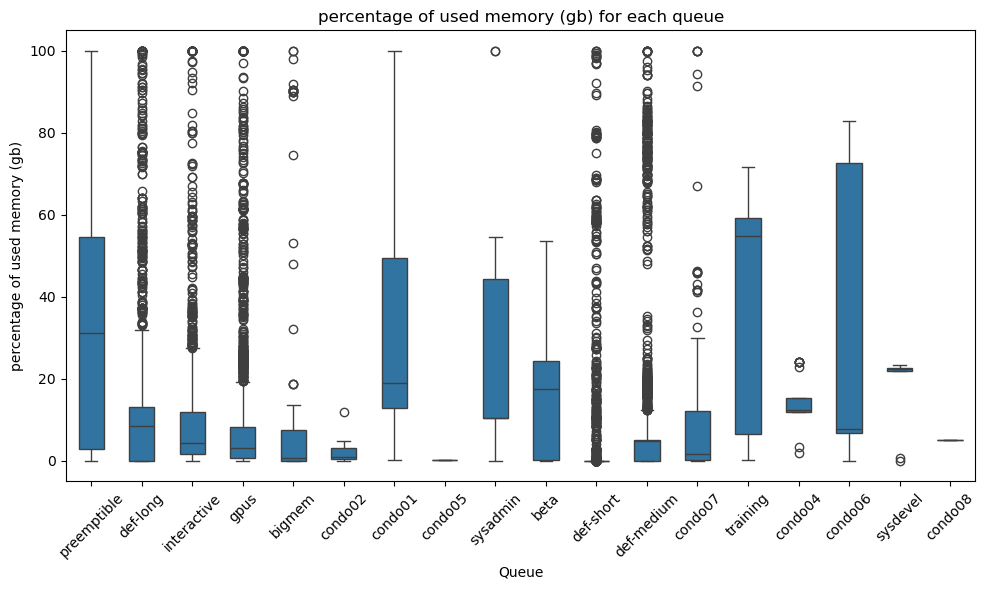

In [ ]:
# calculate a column of requested memory (gb) / used memory (kb) in gb
# clean then convert used memory to gb
df['resources_used.mem'] = df['resources_used.mem'].replace('NaN', np.nan)
df['resources_used.mem'] = df['resources_used.mem'].replace('0b', np.nan)
# df = df.dropna(subset=['resources_used.mem'])
# df['resources_used.mem']

df['resources_used.mem (gb)'] = df['resources_used.mem'] / (1024 * 1024)

df['Resource_List.mem'] = df['Resource_List.mem'].replace('NaN', np.nan)
# df = df.dropna(subset=['Resource_List.mem'])
# df['Resource_List.mem']

df['mem%'] = np.divide(df['resources_used.mem (gb)'], df['Resource_List.mem']) * 100
df['mem%'] = df['mem%'].astype(float)

mem_usage_stat = df['mem%'].describe()
print(mem_usage_stat)

# analyse mem% for each queue
# group by queue and calculate the mean, median, std, min, max of how long in q 
used_mem_percent = df.groupby('queue = ').agg({'mem%': ['mean', 'std', 'min', 'max']})
# print the stats
print(used_mem_percent)




# plot a visualisation of mem% for each queue

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='queue = ', y='mem%', width=0.5)
# sns.boxplot(data=df, x='queue = ', y='mem%', width=0.5, palette='pastel')
# sns.violinplot(data=df, x='queue = ', y='mem%', inner='box', cut=0)
plt.title('percentage of used memory (gb) for each queue')
plt.xlabel('Queue')
plt.ylabel('percentage of used memory (gb)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('percentage of used memory 1.png')
plt.show()

## Analyse [4]: used ncpus of requested ncpus

count    19301.000000
mean        37.256585
std         40.513111
min          0.000000
25%          0.000000
50%         12.718750
75%         84.000000
max        100.000000
Name: used_ncpus%, dtype: float64
            used_ncpus%                                
                   mean        std      min         max
queue =                                                
beta          23.122461  17.108927  0.00000   62.300000
bigmem        14.365307  28.333388  0.00000   99.000000
condo01       63.526804  38.239201  0.00000   99.611111
condo02       37.310547  46.039787  0.00000   99.500000
condo04       25.720238  27.829906  0.00000   97.250000
condo05        3.750000        NaN  3.75000    3.750000
condo06       81.816220  36.258392  0.03125   98.791667
condo07       12.686760  22.692719  0.00000   98.750000
condo08        1.625000        NaN  1.62500    1.625000
def-long      50.813439  45.044519  0.00000  100.000000
def-medium    42.295262  36.514250  0.00000   99.375000
def-sh

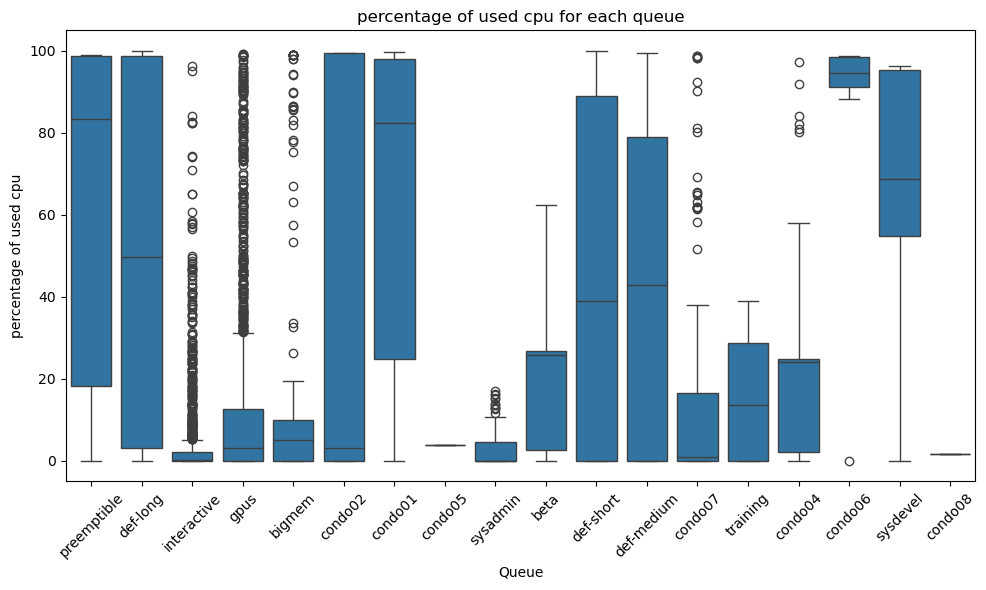

In [7]:
# analyse resources_used.cpupercent for each queue
df['resources_used.cpupercent'] = df['resources_used.cpupercent'].replace('NaN', np.nan)
df['used_ncpus'] = df['resources_used.cpupercent'] / 100


df['used_ncpus%'] = np.divide(df['used_ncpus'], df['Resource_List.ncpus']) * 100


cpu_usage_stat = df['used_ncpus%'].describe()
print(cpu_usage_stat)

# group by queue and calculate the mean, median, std, min, max of how long in q
cpu_percent_per_q = df.groupby('queue = ').agg({'used_ncpus%': ['mean', 'std', 'min', 'max']})
# print the stats
print(cpu_percent_per_q)



# plot a visualisation of cpu percent for each queue
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='queue = ', y='used_ncpus%')
plt.title('percentage of used cpu for each queue')
plt.xlabel('Queue')
plt.ylabel('percentage of used cpu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('percentage of used cpu.png')


## Analyse [5]: distripution of requested ncpus 

count    19894.000000
mean        16.081783
std         24.280265
min          1.000000
25%          1.000000
50%          8.000000
75%         20.000000
max       1344.000000
Name: Resource_List.ncpus, dtype: float64
            Resource_List.ncpus                          
                           mean        std    min     max
queue =                                                  
beta                  30.447761   5.740034   16.0    36.0
bigmem                21.467105  13.923372    1.0    64.0
condo01               34.257519  16.149007    1.0    64.0
condo02               31.482143  32.304877    4.0   128.0
condo04                4.000000   0.000000    4.0     4.0
condo05               32.000000  28.844410    8.0    64.0
condo06              105.142857  39.036003   48.0   128.0
condo07               35.191964  31.646644    1.0   128.0
condo08              192.000000        NaN  192.0   192.0
def-long              15.449767  27.081830    1.0  1344.0
def-medium             7.335

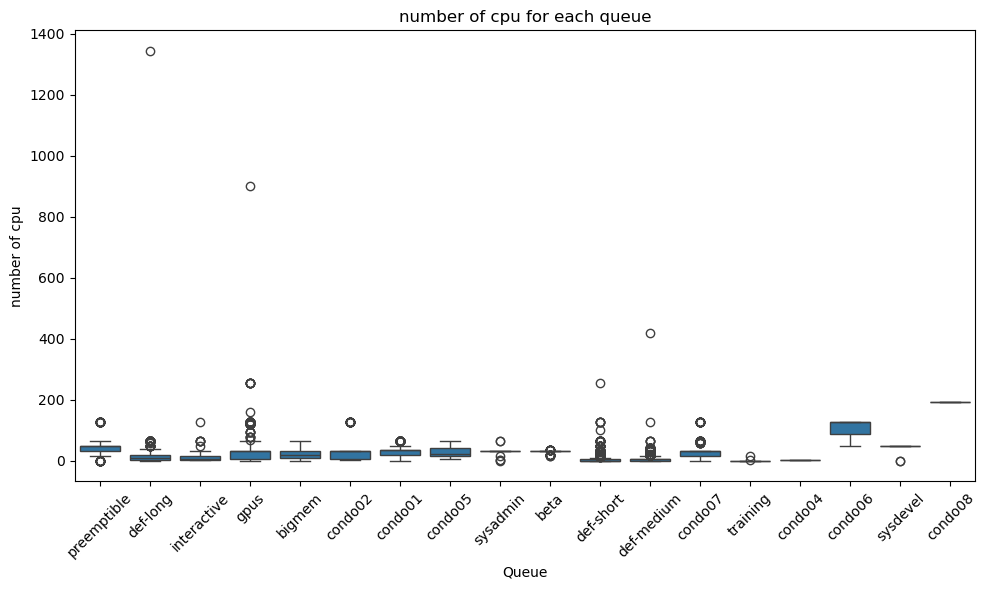

In [8]:
# analyse the distripution of the Resource_List.ncpus 
# group by queue and calculate the mean, median, std, min, max of how long in q
df['Resource_List.ncpus'] = df['Resource_List.ncpus'].replace('NaN', np.nan)
df['Resource_List.ncpus'] = df['Resource_List.ncpus'].astype(float)

cpu_count_stat = df['Resource_List.ncpus'].describe()
print(cpu_count_stat)

# group by queue and calculate the mean, median, std, min, max of how long in q	
cpu_count = df.groupby('queue = ').agg({'Resource_List.ncpus': ['mean', 'std', 'min', 'max']})
# print the stats
print(cpu_count)
# plot a visualisation of cpu count for each queue
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='queue = ', y='Resource_List.ncpus')
plt.title('number of cpu for each queue')
plt.xlabel('Queue')
plt.ylabel('number of cpu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('number of cpu.png')
plt.show()



## Analyse [6]: distripution of requested ngpus 

count    19894.000000
mean         0.388710
std          0.990507
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         24.000000
Name: Resource_List.ngpus, dtype: float64
            Resource_List.ngpus                     
                           mean       std  min   max
queue =                                             
beta                   4.895522  3.927889  0.0   8.0
bigmem                 0.006579  0.114708  0.0   2.0
condo01                0.000000  0.000000  0.0   0.0
condo02                0.272321  0.446151  0.0   1.0
condo04                0.000000  0.000000  0.0   0.0
condo05                0.000000  0.000000  0.0   0.0
condo06                0.000000  0.000000  0.0   0.0
condo07                0.000000  0.000000  0.0   0.0
condo08                4.000000       NaN  4.0   4.0
def-long               0.000000  0.000000  0.0   0.0
def-medium             0.000798  0.036472  0.0   2.0
def-short              0.000000  0.00000

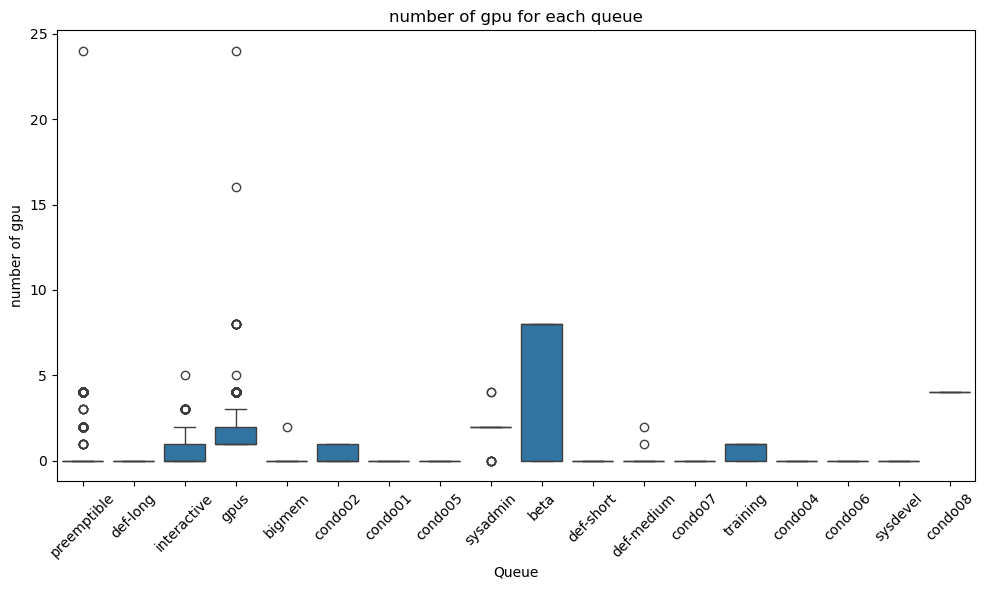

In [9]:
# do the same for Resource_List.ngpus
# group by queue and calculate the mean, median, std, min, max of how long in q
df['Resource_List.ngpus'] = df['Resource_List.ngpus'].replace('NaN', np.nan)
df['Resource_List.ngpus'] = df['Resource_List.ngpus'].astype(float)

gpu_count_stat = df['Resource_List.ngpus'].describe()
print(gpu_count_stat)

# group by queue and calculate the mean, median, std, min, max of how long in q
gpu_count = df.groupby('queue = ').agg({'Resource_List.ngpus': ['mean', 'std', 'min', 'max']})
# print the stats
print(gpu_count)
# plot a visualisation of gpu count for each queue
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='queue = ', y='Resource_List.ngpus')         
plt.title('number of gpu for each queue')
plt.xlabel('Queue')
plt.ylabel('number of gpu')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('number of gpu.png')
plt.show()



## Analyse [7]: total jobs runtime (hours)

In [10]:
# TO DO: Analyse TOTAL Walltime


# # convert df['resources_used.walltime']  from hh:mm:ss to total hours
# def convert_to_hours(walltime):
#     if pd.isna(walltime):
#         return np.nan
#     else:
#         time_parts = walltime.split(':')
#         if len(time_parts) == 3:
#             hours = int(time_parts[0]) + int(time_parts[1]) / 60 + int(time_parts[2]) / 3600
#             return hours
#         else:
#             return np.nan

# df['resources_used.walltime'] = df['resources_used.walltime'].astype(str)
# df['resources_used.walltime']
# # df['resources_used.walltime_hours'] = df['resources_used.walltime'].apply(convert_to_hours)




# # Show descriptive stats
# time_hours_stat = df['resources_used.walltime_hours'].describe()
# print(time_hours_stat)

# # Replace 'queue = ' with correct column name, e.g., 'queue'
# queue_column = 'queue = '  # <-- Change if needed

# # Group by queue and calculate statistics
# time_count = df.groupby(queue_column).agg({
#     'resources_used.walltime_hours': ['mean', 'std', 'min', 'max']
# })
# print(time_count)

# # Plot a visualization of walltime for each queue
# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x=queue_column, y='resources_used.walltime_hours')
# plt.title('Used Walltime (hours)')
# plt.xlabel('Queue')
# plt.ylabel('Running Time (hours)')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig('used_walltime.png')
# plt.show()


## Analyse [8]: distripution of requested nodes 

count    19894.000000
mean         1.007389
std          0.417045
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         42.000000
Name: Resource_List.nodect, dtype: float64
            Resource_List.nodect                     
                            mean       std  min   max
queue =                                              
beta                    1.000000  0.000000  1.0   1.0
bigmem                  1.000000  0.000000  1.0   1.0
condo01                 1.000000  0.000000  1.0   1.0
condo02                 1.000000  0.000000  1.0   1.0
condo04                 1.000000  0.000000  1.0   1.0
condo05                 1.000000  0.000000  1.0   1.0
condo06                 1.000000  0.000000  1.0   1.0
condo07                 1.000000  0.000000  1.0   1.0
condo08                 1.000000       NaN  1.0   1.0
def-long                1.022706  0.733105  1.0  42.0
def-medium              1.010910  0.668814  1.0  42.0
def-short               1

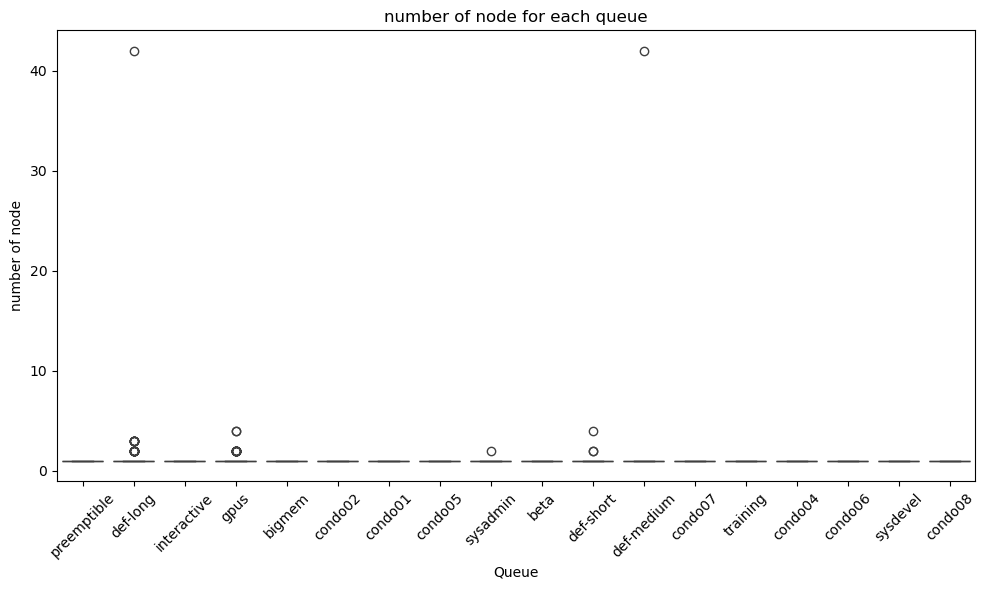

In [11]:
# do the same for Resource_List.nodect
# group by queue and calculate the mean, median, std, min, max of how long in q
df['Resource_List.nodect'] = df['Resource_List.nodect'].replace('NaN', np.nan)
df['Resource_List.nodect'] = df['Resource_List.nodect'].astype(float)

node_count_stat = df['Resource_List.nodect'].describe()
print(node_count_stat)

# group by queue and calculate the mean, median, std, min, max of how long in q
node_count = df.groupby('queue = ').agg({'Resource_List.nodect': ['mean', 'std', 'min', 'max']})
# print the stats
print(node_count)
# plot a visualisation of node count for each queue

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='queue = ', y='Resource_List.nodect')
plt.title('number of node for each queue')
plt.xlabel('Queue')
plt.ylabel('number of node')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('number of node.png')
plt.show()